### Analysis of an E-commerce Dataset

We have been provided with a combined e-commerce dataset. In this dataset, each user has the ability to post a rating and review for the products they purchased. Additionally, other users can evaluate the initial rating and review by expressing their trust or distrust.

This dataset includes a wealth of information for each user. Details such as their profile, ID, gender, city of birth, product ratings (on a scale of 1-5), reviews, and the prices of the products they purchased are all included. Moreover, for each product rating, we have information about the product name, ID, price, and category, the rating score, the timestamp of the rating and review, and the average helpfulness of the rating given by others (on a scale of 1-5).

The dataset is from several data sources, and we have merged all the data into a single CSV file named 'A Combined E-commerce Dataset.csv'. The structure of this dataset is represented in the header shown below.

| userId | gender | rating | review| item | category | helpfulness | timestamp | item_id | item_price | user_city|

    | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- |  ---- |  ---- |  
    
#### Description of Fields

* __userId__ - the user's id
* __gender__ - the user's gender
* __rating__ - the user's rating towards the item
* __review__ - the user's review towards the item
* __item__ - the item's name
* __category__ - the category of the item
* __helpfulness__ - the average helpfulness of this rating
* __timestamp__ - the timestamp when the rating is created
* __item_id__ - the item's id
* __item_price__ - the item's price
* __user_city__ - the city of user's birth

Note that, a user may rate multiple items and an item may receive ratings and reviews from multiple users. The "helpfulness" is an average value based on all the helpfulness values given by others.

There are four questions to explore with the data as shown below.



<img src="data-relation.png" align="left" width="400"/>
(You can find the data relation diagram on iLearn - Portfolio Part 1 resources - Fig1)


In [ ]:
student_name = "Jaya sri Garipally"
student_id = "47822872"

 #### Q1. Remove missing data

Please remove the following records in the csv file:

 * gender/rating/helpfulness is missing
 * review is 'none'

__Display the DataFrame, counting number of Null values in each column, and print the length of the data__ before and after removing the missing data.  

In [1]:
# your code and solutions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# Reading CSV file into a DataFrame using the read_csv function
stat = pd.read_csv('The E-commerce Dataset.csv')
stat.head() # Displays the first few rows of the DataFrame to inspect the structure and content of the data

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4051,12807,Great job for what it is!,eBay,5.0,2.0,F,Online Stores & Services,88,149.00,39
1,4052,122899,Free Access Worth your Time,NetZero,5.0,0.0,F,Online Stores & Services,46,53.00,39
2,33,12700,AOL..I love you!!!!!!!!!!!!,AOL (America Online),5.0,4.0,F,Online Stores & Services,0,145.84,31
3,33,21000,EBAY!!! I LOVE YOU!!!! :-)*,eBay,5.0,4.0,F,Online Stores & Services,88,149.00,31
4,33,22300,Blair Witch...Oh Come On.......,Blair Witch Project,1.0,4.0,F,Movies,12,44.00,31


In [5]:
# Prints a concise summary of the DataFrame, including column data types and non-null counts
stat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   userId       20000 non-null  int64  
 1   timestamp    20000 non-null  int64  
 2   review       20000 non-null  object 
 3   item         20000 non-null  object 
 4   rating       19983 non-null  float64
 5   helpfulness  19978 non-null  float64
 6   gender       19973 non-null  object 
 7   category     20000 non-null  object 
 8   item_id      20000 non-null  int64  
 9   item_price   20000 non-null  float64
 10  user_city    20000 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 1.7+ MB


In [6]:
# Count the number of missing values in each column of the DataFrame
stat.isnull().sum()

userId          0
timestamp       0
review          0
item            0
rating         17
helpfulness    22
gender         27
category        0
item_id         0
item_price      0
user_city       0
dtype: int64

In [7]:
# Print the number of rows in the DataFrame
print (len(stat))

20000


In [8]:
# Counting number of null values in gender, rating and helpfulness
nullCheck1 = stat.rating.isnull().sum()
print(nullCheck1)

nullCheck2 = stat.helpfulness.isnull().sum()
print(nullCheck2)

nullCheck3 = stat.gender.isnull().sum()
print(nullCheck3)


17
22
27


In [9]:
# Counting null values in the 'review' column before removing
removestat =stat.drop(stat.index[(stat['review']=='none')])
print (len(removestat))

# Counting non-null values after removing the rows with 'none' in the 'review' column
good =stat.dropna()
print(len(good))

# the difference between before and after removing the null values in review is 48

19982
19934


#### Q2. Descriptive statistics

With the cleaned data in Q1, please provide the data summarization as below:

* Q2.1 total number of unique users, unique reviews, unique items, and unique categories
* Q2.2 descriptive statistics, e.g., the total number, mean, std, min and max regarding all rating records
* Q2.3 descriptive statistics, e.g., mean, std, max, and min of the number of items rated by different genders
* Q2.4 descriptive statistics, e.g., mean, std, max, min of the number of ratings that received by each items


In [10]:
# your code and solutions
# your code and solutions
# Q 2.1
user = stat['userId'].unique() # Get the unique user IDs from the 'userId' column
print('the number of unique users is', len(user)) # Print the number of unique users

review = stat['review'].unique() # Get the unique reviews from the 'review' column
print('the number of unique review is', len(review)) # Print the number of unique reviews

item = stat['item'].unique() # Get the unique items from the 'item' column
print('the number of unique item is', len(item)) # Print the number of unique items

category = stat['category'].unique() # Get the unique categories from the 'category' column
print('the number of unique category is', len(category)) # Print the number of unique category

the number of unique users is 8580
the number of unique review is 19524
the number of unique item is 89
the number of unique category is 9


In [11]:
# Q2.2
# Generate descriptive statistics of the 'rating' column
stat['rating'].describe()

count    19983.000000
mean         3.701847
std          1.404619
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

In [12]:
# Q2.3
# Group the original DataFrame 'stat' by the 'gender' column
genderstat = stat.groupby(['gender'])
genderstat = genderstat.count()  # Count the number of occurrences of each gender category in the grouped DataFrame
genderstat.describe() # Generate descriptive statistics of the counts in the grouped DataFrame 'genderstat'

,userId,timestamp,review,item,rating,helpfulness,category,item_id,item_price,user_city
count,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
mean,9986.500000,9986.500000,9986.500000,9986.500000,9978.000000,9975.500000,9986.500000,9986.500000,9986.500000,9986.500000
std,236.880772,236.880772,236.880772,236.880772,239.002092,235.466558,236.880772,236.880772,236.880772,236.880772
min,9819.000000,9819.000000,9819.000000,9819.000000,9809.000000,9809.000000,9819.000000,9819.000000,9819.000000,9819.000000
25%,9902.750000,9902.750000,9902.750000,9902.750000,9893.500000,9892.250000,9902.750000,9902.750000,9902.750000,9902.750000
50%,9986.500000,9986.500000,9986.500000,9986.500000,9978.000000,9975.500000,9986.500000,9986.500000,9986.500000,9986.500000
75%,10070.250000,10070.250000,10070.250000,10070.250000,10062.500000,10058.750000,10070.250000,10070.250000,10070.250000,10070.250000
max,10154.000000,10154.000000,10154.000000,10154.000000,10147.000000,10142.000000,10154.000000,10154.000000,10154.000000,10154.000000


In [13]:
#Q 2.4
itemstat = stat.groupby(['item']) # Grouping the original DataFrame 'stat' by the 'item' column
itemstat = itemstat.count() # Counting the occurrences of each item in the grouped DataFrame
itemstat.describe()         # Generating descriptive statistics of the counts in the grouped DataFrame 'itemstat'

,userId,timestamp,review,rating,helpfulness,gender,category,item_id,item_price,user_city
count,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000
mean,224.719101,224.719101,224.719101,224.528090,224.471910,224.415730,224.719101,224.719101,224.719101,224.719101
std,116.923731,116.923731,116.923731,116.841393,116.783414,116.831445,116.923731,116.923731,116.923731,116.923731
min,140.000000,140.000000,140.000000,140.000000,140.000000,139.000000,140.000000,140.000000,140.000000,140.000000
25%,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000
50%,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000
75%,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000
max,944.000000,944.000000,944.000000,944.000000,942.000000,943.000000,944.000000,944.000000,944.000000,944.000000


#### Q3. Plotting and Analysis

Please try to explore the correlation between gender/helpfulness/category and ratings; for instance, do female/male users tend to provide higher ratings than male/female users? Hint: you may use the boxplot function to plot figures for comparison (___Challenge___)
    
You may need to select the most suitable graphic forms for ease of presentation. Most importantly, for each figure or subfigure, please summarise ___what each plot shows___ (i.e. observations and explanations). Finally, you may need to provide an overall summary of the data.

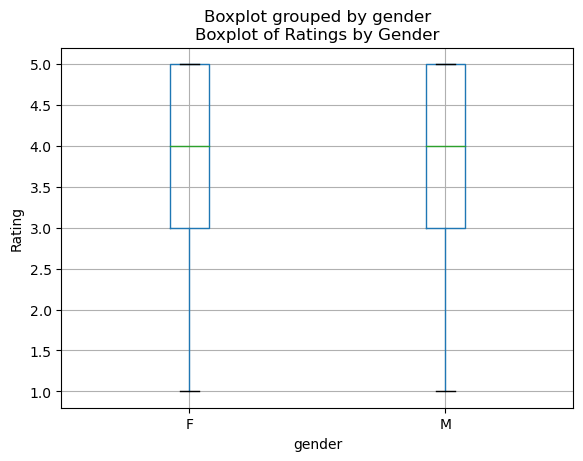

In [14]:
# your code and solutions
# Gender rating correlation
stat.boxplot("rating",by="gender") # Plot a boxplot of ratings grouped by gender
plt.title("Boxplot of Ratings by Gender") # Set the title of the plot
plt.ylabel("Rating")  # Set the title for the y-axis
plt.show() # Display the plot

## Observation for gender rating correleation
- The boxplot comparsion between gender reveals no discemible difference in the ratings they provided. Both genders distributed their ratings evenly across the scale, with score ranging from the minimum of 3 to the maximum of 5.

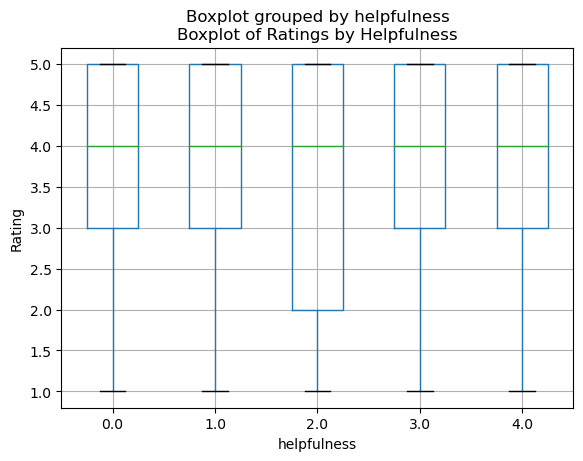

In [25]:
# helpfulness rating correlation
stat.boxplot("rating",by="helpfulness") # plot a boxplot of ratings grouped by helpfulness
plt.title("Boxplot of Ratings by Helpfulness") # Set the title of the plot
plt.ylabel("Rating")  # Set the title for the y-axis
plt.show() # display the plot

## Observation for helpfulness rating correleation
- Visually, the boxplot representation of the data supports this finding, showing a left-skewed distribution.
- While the majority of helpfulness indicators exhibit similar spreads, the helpfulness rating of 2 displays a slightly greater spread

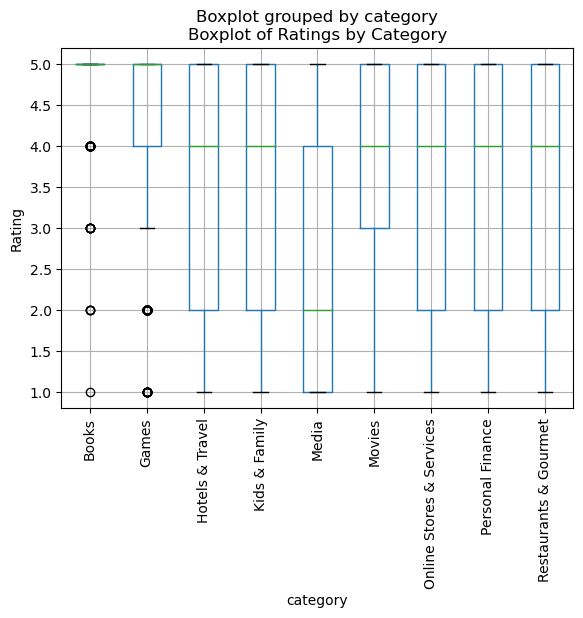

In [26]:
# category rating correlation
stat.boxplot("rating",by="category") # plot a boxplot of ratings grouped by category
plt.xticks(rotation =90) # Rotate the x-axis by 90 degrees for better readability
plt.ylabel("Rating")  # Set the title for the y-axis
plt.title("Boxplot of Ratings by Category") # Set the title of the plot
plt.show() # display the plot

## Observation for category rating correleation
- Unclear preference for rating books, with widespread outliers.
- Left-skewed distribution for games, hinting at a negative rating trend.
- Overall, no strong correlation between ratings and categories, influenced by individual preferences and demographics like age. Hence, the relationship varies based on user characteristics, making it challenging to classify a definitive correlation. 

## Summary of the data
Overall summary of the data the gender and helpfulness exhibit has no significant effect on item ratings, as depicted by the data and boxplots. While the boxplot for category shows some influence on ratings, other factors like age, income, and lifestyle play a more substantial role. Overall, various factors contribute to how users rate an item and its helpfulness to others, with individual characteristics having a significant impact on ratings.

#### Q4. Detect and remove outliers

We may define outlier users, reviews and items with three rules (if a record meets one of the rules, it is regarded as an outlier):

1. reviews of which the helpfulness is no more than 2
2. users who rate less than 7 items
3. items that receives less than 11 ratings

Please remove the corresponding records in the csv file that involves outlier users, reviews and items. You need to follow the order of rules to perform data cleaning operations. After that, __print the length of the data__.

In [17]:
# your code and solutions
# Remove records with helpfulness no more than 2
remove_review = stat.drop(stat.index[stat['helpfulness'] <= 2])

# Print the length of the data after removing outlier reviews
print('The length after removing outlier reviews:', len(remove_review))

The length after removing outlier reviews: 13710


In [18]:
# Group users by their ids and count the number of their ratings
grouped_users = remove_review.groupby(['userId'])['review'].count().reset_index(name='rating_count')

# Print the number of users after removing outlier reviews by counting the number of their ratings
print('The number of users after removing outlier reviews by counting the number of their ratings is', len(grouped_users))

The number of users after removing outlier reviews by counting the number of their ratings is 6561


In [19]:
# Display the first few rows of the grouped users DataFrame
print(grouped_users.head())

   userId  rating_count
0       0             3
1       1             1
2       2             2
3       3             2
4       4             7


In [20]:
# rate less than 7
checking = stat['userId'].value_counts()
userRate = checking[checking > 7].tolist()
print(len(userRate))

364


In [21]:
#  receives less than 11 ratings
receive =stat['item_id'].value_counts()
receive1 = receive[receive > 11].tolist()
print(len(receive1))

89


In [24]:
# removing the outlier
stat1 = stat[stat['userId'].isin(userRate)]
stat1 = stat[stat['item_id'].isin(receive1)]
print("the length of data after removing is", len(stat1))

the length of data after removing is 0
